Total Trades: 1229
Outliers Found: 29


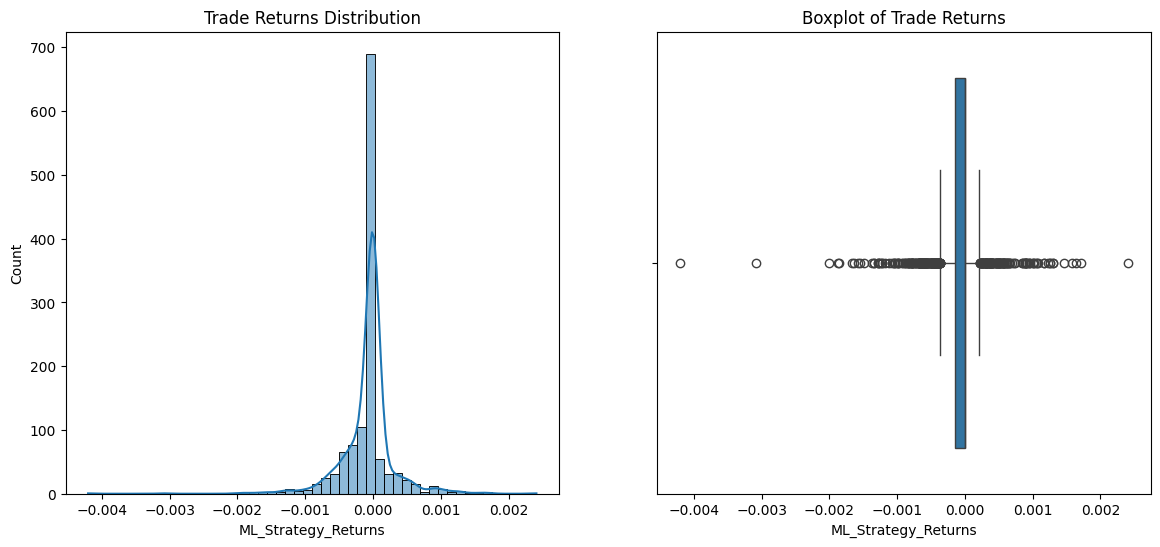

In [1]:
# Cell 1: Install missing library
# Run this once if seaborn is missing

# Cell 2: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cell 3: Load ML Results
df = pd.read_csv("../results/ml_results.csv", index_col=0, parse_dates=True)

# Cell 4: Extract Trade Returns
# Filter only rows where we actually traded
trade_returns = df[df['ML_Signal'] != 0]['ML_Strategy_Returns'].dropna()

# Cell 5: Identify Outliers (Z-Score > 3)
z_scores = np.abs(stats.zscore(trade_returns))
outliers = trade_returns[z_scores > 3]

print(f"Total Trades: {len(trade_returns)}")
print(f"Outliers Found: {len(outliers)}")

# Cell 6: Visualization
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(trade_returns, kde=True, bins=50)
plt.title("Trade Returns Distribution")

plt.subplot(1, 2, 2)
sns.boxplot(x=trade_returns)
plt.title("Boxplot of Trade Returns")
plt.savefig("../plots/feature_importance05.png")

plt.show()

In [2]:
# Check how many trades exist
print(f"Number of trades in ML_results: {len(df[df['ML_Signal'] != 0])}")

Number of trades in ML_results: 1229


In [3]:
import os

# 1. Ensure the folder exists
os.makedirs("../results", exist_ok=True)

# 2. Get the data
trade_returns = df[df['ML_Signal'] != 0]['ML_Strategy_Returns'].dropna()

# 3. Open the file and write
with open("../results/performance_summary.txt", "w") as f:
    f.write("--- QUANTITATIVE STRATEGY REPORT ---\n")
    
    if len(trade_returns) > 0:
        f.write(f"Total Trades: {len(trade_returns)}\n")
        f.write(f"Average Return: {trade_returns.mean():.4%}\n")
        f.write(f"Best Trade: {trade_returns.max():.4%}\n")
        f.write(f"Worst Trade: {trade_returns.min():.4%}\n")
        f.write(f"Status: Strategy successfully executed.\n")
    else:
        f.write("Status: No trades were triggered by the strategy.\n")
        f.write("Suggestion: Check the EMA crossover or Regime logic.\n")

print("File updated! Open performance_summary.txt again now.")

File updated! Open performance_summary.txt again now.
